# Set-up

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
from CIBUSmod.impact.LULUC import LUCParcel, LUCTimeSeries
from CIBUSmod.impact.LULUC import LUCParcel2, LUCTimeSeries2

# LUC for scenarios

## Initiate Session

In [61]:
# MFF scenarios
session = cm.Session(
    name = 'MFF',
    data_path = '../data',
    data_path_output = '../../MFF-scenarios/output'
)

In [51]:
# Base20 and Sust50
# session = cm.Session(
#     name = 'example_scenarios',
#     data_path = '../data'
# )

## Get GHG emissions from model output and calculate temperature response

In [62]:
%%time
ghg = (
    cm.impact.get_GHG(session, CO2eq=None, interpolate=True)
    .rename(lambda x: 'CH4' if 'CH4' in x else ('N2O' if 'N2O' in x else x), axis=1)
    .T.groupby('compound').sum().T
)
dT_GHG = cm.impact.get_deltaT(ghg, extend=50) * 1_000

Getting GHG emissions ...
Calculating temperature response ...
CPU times: total: 51.7 s
Wall time: 51.8 s


## Get land use

In [63]:
# Get land use
lu_df = session.get_attr('C','area',{'crop':'land_use','region':None}, interpolate=True).drop('greenhouse', axis=1)
lu_org = session.get_attr('C', 'organic_soil_area', {'crop':'land_use','region':None}, interpolate=True)
# Separate organic and mineral soils
lu_min = lu_df - lu_org
lu_min = lu_min.rename({
    'cropland' : 'cropland, mineral soil',
    'semi-natural grasslands' : 'semi-natural grasslands, mineral soil'
}, axis=1)
lu_org = lu_org.rename({
    'cropland' : 'cropland, organic soil',
    'semi-natural grasslands' : 'semi-natural grasslands, organic soil'
}, axis=1)
# Combine
lu_df = pd.concat([lu_min,lu_org], axis=1)

## Set paramters for LUC calculations
These are not grounded in anything but only to test. But, hopefully the are sort of in a correct order of magnitude.

In [64]:
extend = 50 # years

# For LUCTimeSeries -------------------------->
LUC_paramters = {
    'cropland, mineral soil' : {
        'Cmax' : (2_000,100_000),
        'T50' : (0.5,20)
    },
    'semi-natural grasslands, mineral soil' : {
        'Cmax' : (25_000,100_000),
        'T50' : (2,20)
    },
    'cropland, organic soil' : {
        'Cmax' : (5_000,80_000),
        'T50' : (0.5,20)
    },
    'semi-natural grasslands, organic soil' : {
        'Cmax' : (30_000,80_000),
        'T50' : (2,20)
    }
}

# For LUCTimeSeries2 ------------------------>
LU_pars = {
    'forest, default' : {
        'Lmax' : 100_000,
        'B1' : 0.02,
        'B2' : 2,
        'm' : 0.01,
        'k' : 0.05,
        'sf' : 0.02,
        'sk' : 0.01
    },
    'forest, mineral' : {
        'Lmax' : 100_000,
        'B1' : 0.02,
        'B2' : 2,
        'm' : 0.01,
        'k' : 0.05,
        'sf' : 0.05,
        'sk' : 0.01
    },
    'cropland, mineral' : {
        'Lmax' : 2_500,
        'B1' : 4,
        'B2' : 1,
        'm' : 1,
        'k' : 0.2,
        'sf' : 0.8,
        'sk' : 0.04
    },
}
LUC_paramters2 = {
    'cropland, mineral soil' : {
        'target_lu_pars' : LU_pars['cropland, mineral'],
        'alt_lu_pars' : LU_pars['forest, mineral']
    },
    'semi-natural grasslands, mineral soil' : {
        'target_lu_pars' : LU_pars['cropland, mineral'],
        'alt_lu_pars' : LU_pars['forest, mineral']
    },
    'cropland, organic soil' : {
        'target_lu_pars' : LU_pars['cropland, mineral'],
        'alt_lu_pars' : LU_pars['forest, mineral']
    },
    'semi-natural grasslands, organic soil' : {
        'target_lu_pars' : LU_pars['cropland, mineral'],
        'alt_lu_pars' : LU_pars['forest, mineral']
    }
}


## Create data frame with `LUCTimeSeries` objects
One `LUCTimeSeries` is created per each of the foour land use categories and for each region and use the parameters defined above. Then the time-series is calculated and stored in the **LUC_df** data frame.

In [65]:
%%time
LUC_df = pd.DataFrame(
    index = lu_df.index.unique('scn'),
    columns = lu_df.columns
)
for scn in LUC_df.index:
    for lu,re in LUC_df.columns:
        Ach = lu_df.loc[scn,(lu,re)].diff().fillna(0)
        LUCts = LUCTimeSeries(
            Ach = Ach,
            extend = extend,
            **LUC_paramters[lu]
        )
        LUCts.calculate_parcels()
        LUC_df.loc[scn,(lu,re)] = LUCts

CPU times: total: 9.36 s
Wall time: 9.38 s


### Get CO2 emissions from LUC and calculate temperature response
Emissions are here aggregated over all land use categories and regions.

In [66]:
%%time
LUC_CO2 = pd.DataFrame(
    index = dT_GHG.index,
    columns = pd.Index(['CO2'], name='compound'),
)
for scn in ghg.index.unique('scn'):
    res = pd.Series(0, index = dT_GHG.index.unique('year'), name='CO2')
    for LUCts in LUC_df.loc[scn]:
        r = LUCts.get_CO2()
        r.index = r.index.astype(str)
        res += r
    LUC_CO2.loc[scn,'CO2'] = res.values
dT_LUC = cm.impact.get_deltaT(LUC_CO2).rename({'CO2':'CO2 (LUC)'}, axis=1) * 1_000

Getting GHG emissions ...
Calculating temperature response ...
CPU times: total: 7.12 s
Wall time: 7.11 s


## Create data frame with `LUCTimeSeries2` objects
One `LUCTimeSeries2` is created per each of the foour land use categories and for each region and use the parameters defined above. Then the time-series is calculated and stored in the **LUC_df** data frame.

In [67]:
%%time
LUC_df = pd.DataFrame(
    index = lu_df.index.unique('scn'),
    columns = lu_df.columns
)
for scn in LUC_df.index:
    for lu,re in LUC_df.columns:
        Ach = lu_df.loc[scn,(lu,re)].diff().fillna(0)
        LUCts = LUCTimeSeries2(
            Ach = Ach,
            extend = extend,
            **LUC_paramters2[lu]
        )
        LUCts.calculate_parcels()
        LUC_df.loc[scn,(lu,re)] = LUCts

CPU times: total: 12.9 s
Wall time: 13 s


### Get CO2 emissions from LUC and calculate temperature response
Emissions are here aggregated over all land use categories and regions.

In [68]:
%%time
LUC_CO2 = pd.DataFrame(
    index = dT_GHG.index,
    columns = pd.Index(['CO2'], name='compound'),
)
for scn in ghg.index.unique('scn'):
    res = pd.Series(0, index = dT_GHG.index.unique('year'), name='CO2')
    for LUCts in LUC_df.loc[scn]:
        r = LUCts.get_CO2().sum(axis=1)
        r.index = r.index.astype(str)
        res += r
    LUC_CO2.loc[scn,'CO2'] = res.values
dT_LUC2 = cm.impact.get_deltaT(LUC_CO2).rename({'CO2':'CO2 (LUC)'}, axis=1) * 1_000

Getting GHG emissions ...
Calculating temperature response ...
CPU times: total: 12.6 s
Wall time: 12.7 s


## Combine temperature responses from GHG emissions and LUC CO2

In [69]:
dT = pd.concat([dT_GHG,dT_LUC], axis=1)
dT['TOT'] = dT.sum(axis=1)

dT2 = pd.concat([dT_GHG,dT_LUC2], axis=1)
dT2['TOT'] = dT2.sum(axis=1)

## Plot results

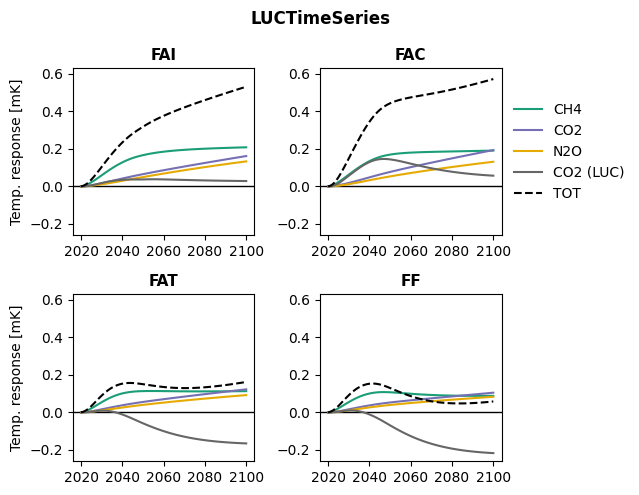

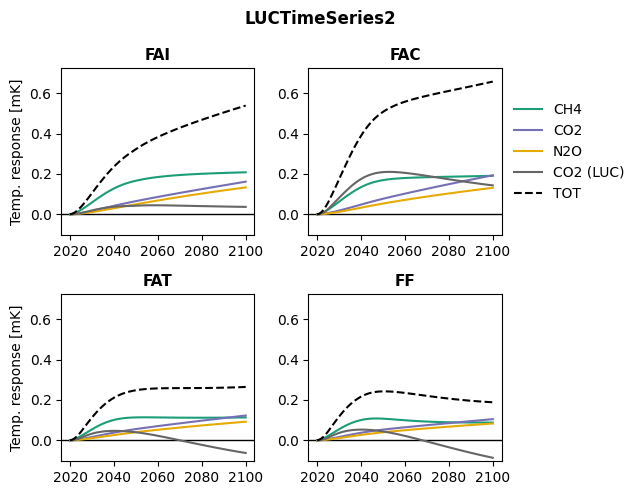

In [70]:
for t,df in zip(['LUCTimeSeries','LUCTimeSeries2'],[dT,dT2]):
    fig,axs = plt.subplots(2,2, figsize=(6.5,5))
    for ax,scn in zip(axs.flatten(),dT.index.unique('scn')):
        ax.axhline(0, color='black', linewidth=1)
        df.loc[scn].iloc[:,:-1].plot(ax=ax, cmap='Dark2', legend=False)
        df.loc[scn].iloc[:,[-1]].plot(ax=ax, linestyle='--', color='black', legend=False)
        ax.set_ylim(df.min().min()*1.2, df.max().max()*1.1)
        ax.set_title(scn, size=11, fontweight='bold')
        if ax in axs.T[0]:
            ax.set_ylabel('Temp. response [mK]')
        ax.set_xlabel('')
        if ax == axs[0][1]:
            ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False)
    
    fig.suptitle(t, fontweight='bold')
    plt.tight_layout()
    plt.show()

# LUC for constructed time-series

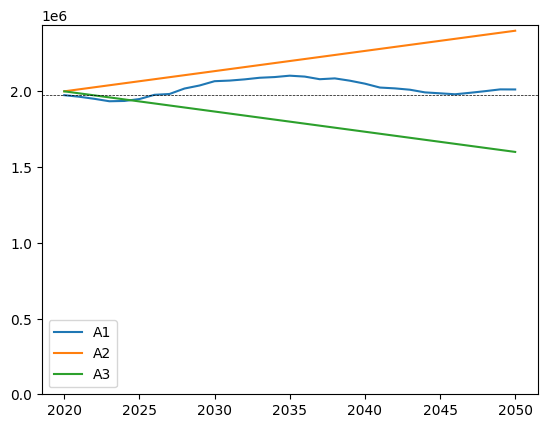

In [22]:
import matplotlib.pyplot as plt

# Generate land use time series
A = {}
A0 = 2_000_000
At = A0
for t in range(2020,2050+1):
    Ach = -np.sin(t/4)*(A0/100) + np.random.randn()*(A0/100/2)
    At += Ach
    A.update({t:At})
    
A1 = pd.Series(A)
A2 = pd.Series({y:At for y,At in zip(range(2020,2050+1),np.linspace(A0,A0*1.2,31))})
A3 = pd.Series({y:At for y,At in zip(range(2020,2050+1),np.linspace(A0,A0*0.8,31))})

ax = A1.plot(label='A1')
A2.plot(ax=ax, label='A2')
A3.plot(ax=ax, label='A3')
ax.axhline(A1.iloc[0], color='black', linestyle='--',linewidth=0.5)
ax.set_ylim(0)
ax.legend()
plt.show()

In [71]:
Ach = A3.diff().fillna(0)

<Axes: >

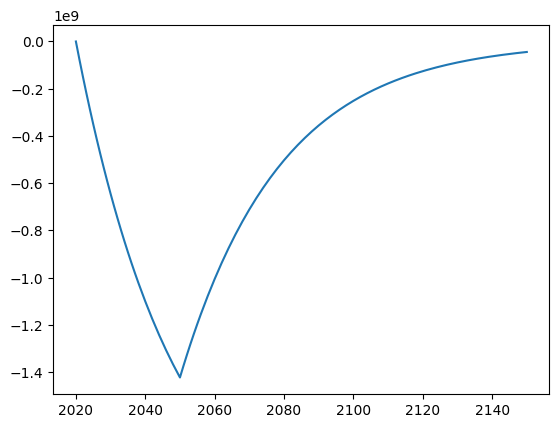

In [72]:
LUCts = LUCTimeSeries(
    Ach = Ach,
    Cmax = (5_000,50_000),
    T50 = (0.5,20),
    extend = 100
)
LUCts.calculate_parcels()
LUCts.get_CO2().plot()

<Axes: xlabel='year'>

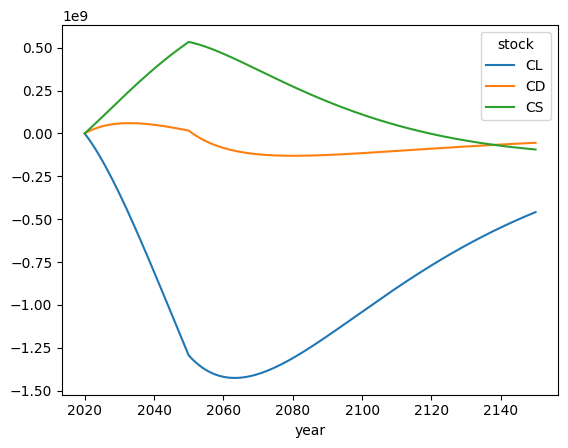

In [73]:
LUCts = LUCTimeSeries2(
    Ach = Ach,
    target_lu_pars=LU_pars['cropland, mineral'],
    alt_lu_pars=LU_pars['forest, mineral'],
    extend = 100
)
LUCts.calculate_parcels()
LUCts.get_CO2().plot()